In [36]:
%load_ext autoreload
%autoreload 2
import os, sys, time
os.environ["OMP_NUM_THREADS"] = "2"

import matplotlib.pyplot                            as plt
import numpy                                        as np
from scipy              import linalg               as LA

from scipy.optimize              import approx_fprime
from sop_lake.utils              import numerical_grad
from sop_lake.SOP                import adapt_residues, SOP
from sop_lake.dmft_config        import load_sim_config
from sop_lake.data_io            import read_conv_history, read_dmft_data, read_vemb_data
from sop_lake.embedding_utils    import frequency_axis, compute_avg_GF, DOS_diff, self_consistency_DMFT
from sop_lake.cost_fn_nogrid     import cost_func_scalar_nogrid, grad_cost_func_scalar_nogrid
from sop_lake.read_old_code      import read_DMFT_output, read_vemb_output, self_consistency_step
from sop_lake.mbAIMSOP_solver    import make_GF_params_SOP


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Color palettes
palette          = ["#822D8A","#D8BFD8"]
vik_red_palette  = ["#044F88","#4F93B5", "#902B05","#C26F40","#F4B400", "#1B9E77","#8BC34A", "#6A3D9A","#CE5B9E"]
palette_7        = ["#9C575E", "#8764A4", "#C67281", "#52A09C", "#5386C2", "#325277", "#E5877C", "#C4A277", "#627C4C"]
prx_palette      = ["#004181","#76BBFE","#F7899E", "#A90307"]                    # From paper Mario Motta
hc_palette       = ["#a50026","#d73027","#f46d43","#fdae61","#fee090","#ffffbf","#e0f3f8","#abd9e9","#74add1", "#4575b4","#313695"]
Ferretti_palette = ['#000000', '#c30201', '#ff6904', '#ffbd83', '#799a9d'] 


In [6]:
single_col_wd = 3.37  # in inches
double_col_wd = 7.0   # in inches
max_height    = 8.5   # in inches

plt.rcParams.update({
    "font.family": "DejaVu Sans",           # Also: "STIXGeneral"
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "lines.linewidth": 2.0,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.8,
    "xtick.major.size": 2.5,
    "xtick.labelsize": 10,
    "ytick.major.width": 0.8,
    "ytick.labelsize": 10,
    "axes.labelsize": 10,
    "ytick.major.size": 2.5,
})

def golden_height(wd):
    return (wd / 1.618)


# Reading simulation output files

In [29]:
dir_name  = "/Users/acarbone/Desktop/tests/U=1/test_3"
sim_config = load_sim_config(dir_name + "/config.yaml")
w_list, Gimp_SOP, Gloc_list, SigmaA_list = read_dmft_data(dir_name + "/dmft_output.json")
vemb_list, SOP_vemb = read_vemb_data(dir_name + "/vemb_output.json")
conv_history = read_conv_history(dir_name + "/conv_output.json")

dir_name2 = "/Users/acarbone/Desktop/tests/U=1/test_4" 
sim_config2 = load_sim_config(dir_name2 + "/config.yaml")
w_list2, Gimp_SOP2, Gloc_list2, SigmaA_list2 = read_dmft_data(dir_name2 + "/dmft_output.json")
vemb_list2, SOP_vemb2 = read_vemb_data(dir_name2 + "/vemb_output.json")
conv_history2 = read_conv_history(dir_name2 + "/conv_output.json")


In [43]:
# Convergence plots
plt.figure()
plt.plot(conv_history["iter"][1:],conv_history["diff_prev"][1:],label=r"$d^2_\text{prev}$ 1")
plt.plot(conv_history["iter"][1:],conv_history["diff_loc"][1:],label=r"$d^2_\text{loc}$ 1")
plt.plot(conv_history2["iter"][1:],conv_history2["diff_prev"][1:],label=r"$d^2_\text{prev}$ 2")
plt.plot(conv_history2["iter"][1:],conv_history2["diff_loc"][1:],label=r"$d^2_\text{loc}$ 2")
plt.legend()
plt.yscale("log")

print("Test 1")
print("Poles: ",SOP_vemb.sigma_list)
res_list = adapt_residues(SOP_vemb.Gamma_list,SOP_vemb.p_type,"std")
print("Residues: ", res_list)

print("\nTest 2")
print("Poles: ",SOP_vemb2.sigma_list)
res_list2 = adapt_residues(SOP_vemb2.Gamma_list,SOP_vemb2.p_type,"std")
print("Residues: ", res_list2)

axis, eta_axis, num_pts, w_edges, matsubara_params = sim_config.embedding.axis, sim_config.embedding.eta_axis, sim_config.embedding.num_pts, sim_config.embedding.w_edges, sim_config.embedding.matsubara_params
w_list, w_sim_list = frequency_axis(axis, eta_axis, num_pts, matsubara_params, w_edges)
Gimp_list = Gimp_SOP.evaluate(w_sim_list)

axi2, eta_axis2, num_pts2, w_edges2, matsubara_params2 = sim_config2.embedding.axis, sim_config2.embedding.eta_axis, sim_config2.embedding.num_pts, sim_config2.embedding.w_edges, sim_config2.embedding.matsubara_params
w_list2, w_sim_list2 = frequency_axis(axi2, eta_axis2, num_pts2, matsubara_params2, w_edges2)
Gimp_list2 = Gimp_SOP2.evaluate(w_sim_list2)
plt.figure()
plt.plot(w_list, np.array(Gimp_list).real[:,0,0], label=r"Re$G_\text{imp}$ 1")
plt.plot(w_list, np.array(Gimp_list).imag[:,0,0], label=r"Im$G_\text{imp}$ 1")
plt.plot(w_list2, np.array(Gimp_list2).real[:,0,0], ls="--", label=r"Re$G_\text{imp}$ 2")
plt.plot(w_list2, np.array(Gimp_list2).imag[:,0,0], ls="--", label=r"Im$G_\text{imp}$ 2")
plt.legend()
plt.ylim(-1,1)
plt.xlim(-5,5)


Test 1
Poles:  [(-0.9733286267203922+0j), (-0.20388705242378913+0j), (-0.0386978026516097+0j), (-0.006773220639919289+0j), (0.006773220639919289+0j), (0.0386978026516097+0j), (0.20388705242378913+0j), (0.9733286267203922+0j)]
Residues:  [array([[0.7015017+0.j, 0.       +0.j],
       [0.       +0.j, 0.7015017+0.j]]), array([[0.21640129+0.j, 0.        +0.j],
       [0.        +0.j, 0.21640129+0.j]]), array([[0.04007668+0.j, 0.        +0.j],
       [0.        +0.j, 0.04007668+0.j]]), array([[0.00991175+0.j, 0.        +0.j],
       [0.        +0.j, 0.00991175+0.j]]), array([[0.00991175+0.j, 0.        +0.j],
       [0.        +0.j, 0.00991175+0.j]]), array([[0.04007668+0.j, 0.        +0.j],
       [0.        +0.j, 0.04007668+0.j]]), array([[0.21640129+0.j, 0.        +0.j],
       [0.        +0.j, 0.21640129+0.j]]), array([[0.7015017+0.j, 0.       +0.j],
       [0.       +0.j, 0.7015017+0.j]])]

Test 2
Poles:  [(-0.9006392416538992+0j), (-0.14449271797273924+0j), (-0.01243187825300548+0j), (

(-5.0, 5.0)

# Comparing new with old code

In [44]:
# New code
num_simul = 6
dir_name  = "/Users/acarbone/Desktop/tests/U=1/test_" + str(num_simul)
sim_config = load_sim_config(dir_name + "/config.yaml")
w_list, Gimp_SOP, Gloc_list, SigmaA_list = read_dmft_data(dir_name + "/dmft_output.json")
vemb_list, SOP_vemb = read_vemb_data(dir_name + "/vemb_output.json")
conv_history = read_conv_history(dir_name + "/conv_output.json")
ntot = Gimp_SOP.dim

axis, eta_axis, num_pts, w_edges, matsubara_params = sim_config.embedding.axis, sim_config.embedding.eta_axis, sim_config.embedding.num_pts, sim_config.embedding.w_edges, sim_config.embedding.matsubara_params
w_list, w_sim_list = frequency_axis(axis, eta_axis, num_pts, matsubara_params, w_edges)
Gimp_list = Gimp_SOP.evaluate(w_sim_list)

# Old code
num_simul2 = 30
dir_name2 = "/Users/acarbone/Desktop/U=1/mu=0.5/N=1000/Results_" + str(num_simul2)
parameters2, conv_list2, output_list2 = read_DMFT_output(dir_name2 + "/DMFT_output.txt",ntot)
vemb_list2, Gamma_list2, sigma_list2 = read_vemb_output(dir_name2 + "/vemb_output.txt",ntot,len(output_list2[0]))
w_edges2 = [-parameters2["w_edge"], parameters2["w_edge"]] if parameters2["w_edge"] is not None else None
matsubara_params2 = {"beta": parameters2["beta_T"], "Nw_max": parameters2["Nw_max"]}
w_list2, w_sim_list2 = frequency_axis(parameters2["axis"], parameters2["eta_axis"], num_pts=parameters2["wgrid_len"],matsubara_params=matsubara_params2, w_edges=w_edges2)
Gloc_list2, A_list2, Z_list2 = output_list2[0], output_list2[2], output_list2[3]
Gimp_list2 = compute_avg_GF(A_list2,Z_list2,w_sim_list2)


In [ ]:
if np.allclose(w_list, w_list2):
    d = DOS_diff(Gimp_list, Gimp_list2)
    print("DOS difference Gimp [axis = {}, eta_axis = {}]: {}".format(sim_config.embedding.axis, sim_config.embedding.eta_axis, d))
    d2 = DOS_diff(Gloc_list, Gloc_list2)
    print("DOS difference Gloc [axis = {}, eta_axis = {}]: {}".format(sim_config.embedding.axis, sim_config.embedding.eta_axis, d2))
    
eta_erf, num_pts_erf = 0.2, 10000
_, w_erf_list   = frequency_axis("erf", eta_erf, num_pts_erf, w_edges=[-10, 10])                        # Comparison axis!

epsk_list, hA_1 = sim_config.system.epsk_list, sim_config.system.get_single_particle_hA()               # N.B. We assume those are the same for both simulations
Gimp_list3 = Gimp_SOP.evaluate(w_erf_list)
SigmaA_list3, Gloc_list3 = self_consistency_DMFT(SOP_vemb,Gimp_SOP,epsk_list,hA_1,w_erf_list,conv_history["mu"][-1],paramagnetic=sim_config.optimization.paramagnetic)

SOP_vemb2 = SOP(Gamma_list2, sigma_list2, parameters2["p_type"])
Gimp_list4 = compute_avg_GF(A_list2,Z_list2,w_erf_list)
SigmaA_list4, Gloc_list4 = self_consistency_step(Gamma_list2,sigma_list2,A_list2,Z_list2,epsk_list,hA_1,w_erf_list,conv_list2["mu_list"][-1],p_type=parameters2["p_type"],paramagnetic=sim_config.optimization.paramagnetic)

d3 = DOS_diff(Gimp_list3, Gimp_list4)
print("DOS difference Gimp [axis = {}, eta_axis = {}]: {}".format("erf", eta_erf, d3))
d4 = DOS_diff(Gloc_list3, Gloc_list4)
print("DOS difference for Gloc [axis = {}, eta_axis = {}]: {}".format("erf", eta_erf, d4))


DOS difference Gimp [axis = erf, eta_axis = 0.2]: 2.9475976744659012e-05
DOS difference for Gloc [axis = erf, eta_axis = 0.2]: 1.7040280122165413e-05


(-2.0, 2.0)

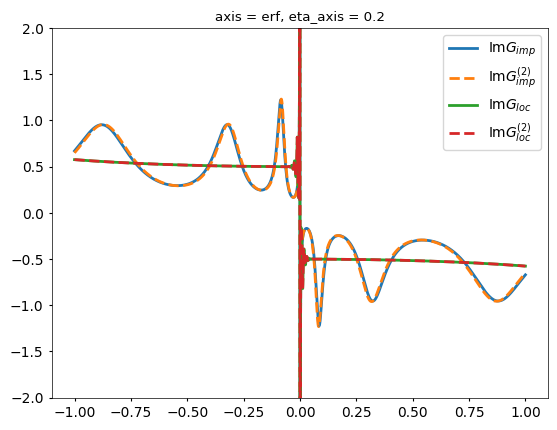

In [47]:
i, j = 0, 0
if np.allclose(w_list, w_list2):
    plt.figure()
    plt.title("axis = {}, eta_axis = {}".format(sim_config.embedding.axis, sim_config.embedding.eta_axis))
    plt.plot(w_list,np.array(Gloc_list).imag[:,i,j],label=r"Im$G_{loc}$")
    plt.plot(w_list2,np.array(Gloc_list2).imag[:,i,j],label=r"Im$G_{loc}^{(2)}$",ls="--")
    plt.plot(w_list,np.array(Gimp_list).imag[:,i,j],label=r"Im$G_{imp}$")
    plt.plot(w_list2,np.array(Gimp_list2).imag[:,i,j],label=r"Im$G_{imp}^{(2)}$",ls="--")
    plt.legend()

plt.figure()
plt.title("axis = {}, eta_axis = {}".format("erf", eta_erf))
plt.plot(np.array(w_erf_list).real,np.array(Gimp_list3).imag[:,i,j],label=r"Im$G_{imp}$")
plt.plot(np.array(w_erf_list).real,np.array(Gimp_list4).imag[:,i,j],label=r"Im$G_{imp}^{(2)}$",ls="--")
plt.plot(np.array(w_erf_list).real,np.array(Gloc_list3).imag[:,i,j],label=r"Im$G_{loc}$")
plt.plot(np.array(w_erf_list).real,np.array(Gloc_list4).imag[:,i,j],label=r"Im$G_{loc}^{(2)}$",ls="--")
plt.legend()
plt.ylim(-2,2)


# Testing gradient without grid

In [33]:
axis, eta_axis, num_pts, w_edges = "erf", 0.5, 5000, [-10,10]
w_list, w_test_list = frequency_axis(axis, eta_axis, num_pts=num_pts,w_edges=w_edges)
num_poles = 5
Gammav_list, sigmav_list = np.linspace(0.9,1.,num_poles).tolist(), np.linspace(-5.,5.,num_poles).tolist()
# v_emb_list = evaluate_SOP(Gammav_list,sigmav_list,w_test_list,p_type="std")
# plt.plot(w_list,np.array(v_emb_list).real,label=r"$Rev_{emb}$",lw=3)
# plt.plot(w_list,np.array(v_emb_list).imag,label=r"$Imv_{emb}$",lw=3)
# plt.legend()

p_type = "std"
Gamma_list, sigma_list = [Gammav - 0.2 * np.random.rand() * 0.4 for Gammav in Gammav_list], [sigmav - 0.2 * np.random.rand() * 0.4 for sigmav in sigmav_list]

cost = cost_func_scalar_nogrid(Gammav_list,sigmav_list,Gamma_list,sigma_list,p_type=p_type)
print("cost = {}".format(cost))


cost = 18.209787308539564


In [34]:
grad = np.array(grad_cost_func_scalar_nogrid(Gammav_list,sigmav_list,Gamma_list,sigma_list,p_type=p_type))               # Gradient of the cost function
# print("Gradient of scalar v_emb: ",*grad)
num_poles = len(sigma_list)
f  = lambda x: cost_func_scalar_nogrid(Gammav_list,sigmav_list,x[:num_poles],x[num_poles:],p_type=p_type)                # Cost function for the simplified dynamics of poles
delta = 1e-8
x0 = Gamma_list + sigma_list

# Comparing Alessandro's analytical gradient with the one of SciPy
t0 = time.time() 
fprime = approx_fprime(x0,f,delta)
t1 = time.time()
# print("      Time to evaluate Scipy numerical gradient - Total time: ",t1 - t0)
print("Comparing Alessandro's and SciPy numerical gradient: ", np.allclose(fprime,grad))
print("Comparing Alessandro's and SciPy gradient directions: {}".format(np.dot(fprime,grad) / (LA.norm(fprime) * LA.norm(grad))))
print(*(fprime - grad),"\n")

# Comparing Alessandro's analytical gradient with a numerical gradient implemented by us
t2 = time.time()
fprime2 = numerical_grad(f,x0,delta)
t3 = time.time()
# print("      Time to evaluate the numerical gradient - Total time: ",t3 - t2)
print("Comparing Alessandro's and numerical gradient: ", np.allclose(fprime2,grad))
print("Comparing Alessandro's and numerical gradient directions: {}".format(np.dot(fprime2,grad) / (LA.norm(fprime2) * LA.norm(grad))))
print(*(fprime2 - grad),"\n")

# Check of parabolic behavior at the minimum
# delta = 1e-10
# x = x0 - delta * grad
# print("Is the SD correct?",f(x) - f(x0),-delta * LA.norm(grad)**2)


Comparing Alessandro's and SciPy numerical gradient:  False
Comparing Alessandro's and SciPy gradient directions: 0.1450050247862257
-6.345468422491834 2.5597693443727394 1.3577289840296487 3.287900762729045 -4.332567147981067 147.23808838476745 3.2551433938952306 115.50911634809012 78.8151651322036 168.2551370633639 

Comparing Alessandro's and numerical gradient:  True
Comparing Alessandro's and numerical gradient directions: 1.0
-4.49201891683515e-07 5.894651167182019e-08 2.9899328524152224e-07 -5.662453403942891e-07 -1.317180107207605e-07 3.5157287925358105e-07 3.9424019515621467e-07 -5.899381818608163e-07 1.1370025845280907e-06 1.1952703005135845e-06 

